<a href="https://colab.research.google.com/github/vivekjain060305-coder/Wine_Quality_Prerdiction/blob/main/Artificial_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving wine-quality-white-and-red (1).csv to wine-quality-white-and-red (1) (1).csv


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
========== RESULTS ==========

80-20 Split
Accuracy: 82.15
Precision Score: 0.5714
F1 Score: 0.42
AUC Score: 0.8512

70-30 Split
Accuracy: 82.0
Precision Score: 0.5534
F1 Score: 0.4524
AUC Score: 0.8382


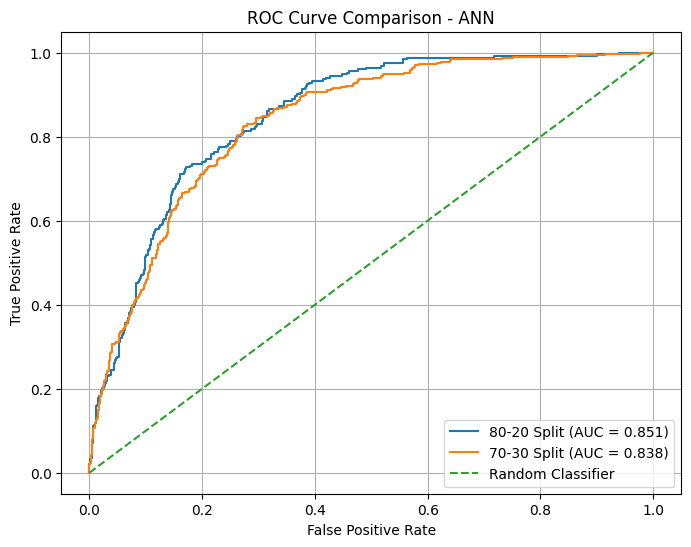

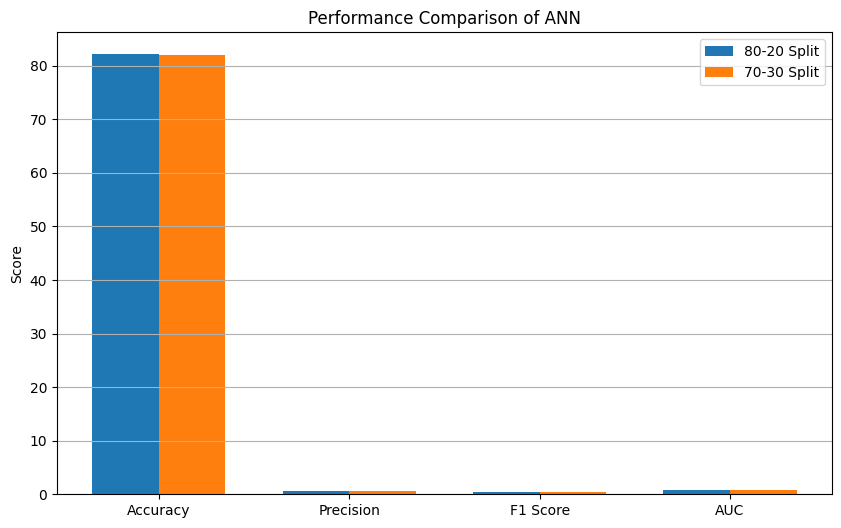

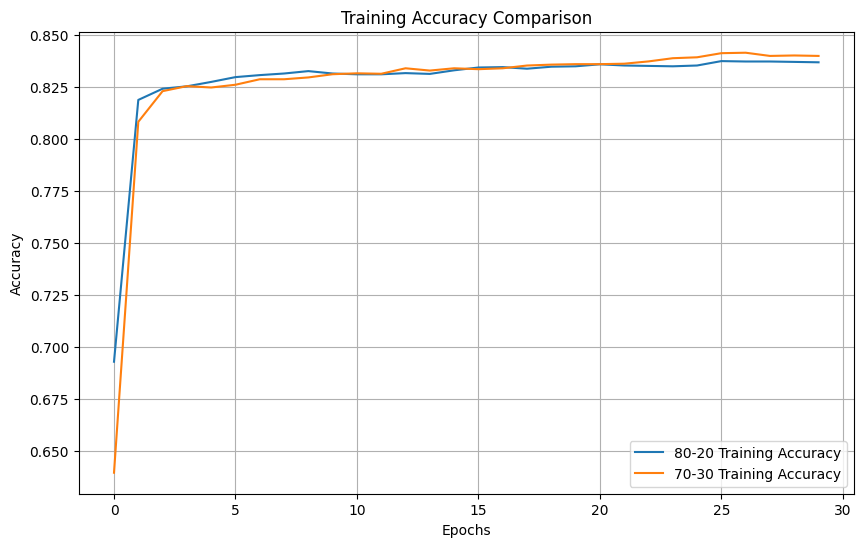

In [2]:
# ============================================
# WINE QUALITY PREDICTION USING ANN
# Comparing 80-20 and 70-30 train-test splits
# ============================================

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_curve, roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Optional: for same result every time
np.random.seed(42)
tf.random.set_seed(42)

# Step 2: Upload dataset
from google.colab import files
uploaded = files.upload()

# Step 3: Load dataset
df = pd.read_csv("wine-quality-white-and-red (1).csv")

# Step 4: Convert quality to binary classification
df["quality_label"] = (df["quality"] >= 7).astype(int)

# Step 5: Convert 'type' column to numerical using one-hot encoding
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# Step 6: Features and target
X = df.drop(["quality", "quality_label"], axis=1)
y = df["quality_label"]

# Function to train and evaluate model for a given split
def train_and_evaluate(test_size, split_name):
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Feature scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Build ANN model
    model = Sequential()
    model.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Compile model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train model
    history = model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)

    # Predictions
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred) * 100
    precision = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_test, y_pred_prob)

    # ROC data
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

    return {
        "split_name": split_name,
        "accuracy": accuracy,
        "precision": precision,
        "f1": f1,
        "auc": auc_score,
        "fpr": fpr,
        "tpr": tpr,
        "history": history
    }

# Step 7: Run both splits
result_80_20 = train_and_evaluate(0.2, "80-20 Split")
result_70_30 = train_and_evaluate(0.3, "70-30 Split")

# Step 8: Print results
print("========== RESULTS ==========")
print(f"\n{result_80_20['split_name']}")
print("Accuracy:", round(result_80_20["accuracy"], 2))
print("Precision Score:", round(result_80_20["precision"], 4))
print("F1 Score:", round(result_80_20["f1"], 4))
print("AUC Score:", round(result_80_20["auc"], 4))

print(f"\n{result_70_30['split_name']}")
print("Accuracy:", round(result_70_30["accuracy"], 2))
print("Precision Score:", round(result_70_30["precision"], 4))
print("F1 Score:", round(result_70_30["f1"], 4))
print("AUC Score:", round(result_70_30["auc"], 4))

# Step 9: Plot ROC curves for both splits
plt.figure(figsize=(8, 6))
plt.plot(result_80_20["fpr"], result_80_20["tpr"], label=f"80-20 Split (AUC = {result_80_20['auc']:.3f})")
plt.plot(result_70_30["fpr"], result_70_30["tpr"], label=f"70-30 Split (AUC = {result_70_30['auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - ANN")
plt.legend()
plt.grid(True)
plt.show()

# Step 10: Bar graph comparison of metrics
metrics = ["Accuracy", "Precision", "F1 Score", "AUC"]
values_80_20 = [
    result_80_20["accuracy"],
    result_80_20["precision"],
    result_80_20["f1"],
    result_80_20["auc"]
]
values_70_30 = [
    result_70_30["accuracy"],
    result_70_30["precision"],
    result_70_30["f1"],
    result_70_30["auc"]
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, values_80_20, width, label="80-20 Split")
plt.bar(x + width/2, values_70_30, width, label="70-30 Split")
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Performance Comparison of ANN")
plt.legend()
plt.grid(axis='y')
plt.show()

# Step 11: Plot training accuracy graph
plt.figure(figsize=(10, 6))
plt.plot(result_80_20["history"].history["accuracy"], label="80-20 Training Accuracy")
plt.plot(result_70_30["history"].history["accuracy"], label="70-30 Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()